# Informer Model Evaluation for Kubernetes Pod Autoscaling

**Objective**: Evaluate the Informer transformer model for proactive pod count prediction and compare against baseline methods including Kubernetes HPA.

In [28]:
%pip install pandas numpy scikit-learn tensorflow matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [29]:
# Standard imports
import numpy as np
import pandas as pd
import pickle
import glob
import os
import time
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import get_custom_objects

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# =============================================================================
# Custom Layers for Informer Model
# =============================================================================

def positional_encoding(length, depth):
    depth = int(depth / 2)
    positions = np.arange(length)[:, np.newaxis]
    depths = np.arange(depth)[np.newaxis, :] / depth
    angle_rates = 1 / (10000 ** depths)
    angle_rads = positions * angle_rates
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)


class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.sequence_length = sequence_length
        self.pos_encoding = positional_encoding(length=sequence_length, depth=d_model)

    def call(self, x):
        length = tf.shape(x)[1]
        return x + self.pos_encoding[tf.newaxis, :length, :]

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "d_model": self.d_model})
        return config


class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, d_model, num_heads, dropout_rate=0.0, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.d_model = d_model
        self.dropout_rate = dropout_rate
        self.depth = d_model // num_heads

    def build(self, input_shape):
        self.wq = layers.Dense(self.d_model)
        self.wk = layers.Dense(self.d_model)
        self.wv = layers.Dense(self.d_model)
        self.dense = layers.Dense(self.d_model)
        self.dropout = layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, training=False, mask=None):
        batch_size = tf.shape(q)[0]
        q, k, v = self.wq(q), self.wk(k), self.wv(v)
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        if mask is not None:
            scaled_attention_logits += (mask * -1e9)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        output = tf.transpose(output, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(output, (batch_size, -1, self.d_model))
        return self.dropout(self.dense(concat_attention), training=training), attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"num_heads": self.num_heads, "d_model": self.d_model, "dropout_rate": self.dropout_rate})
        return config


class OptimizedTransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.2, activation='gelu', **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.dff = dff
        self.dropout_rate = dropout_rate
        self.activation = activation

    def build(self, input_shape):
        self.mha = MultiHeadSelfAttention(self.d_model, self.num_heads, dropout_rate=self.dropout_rate)
        self.ffn_block = keras.Sequential([
            layers.Dense(self.dff, activation=self.activation),
            layers.Dense(self.d_model)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(self.dropout_rate)
        self.dropout2 = layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, x, training=False, mask=None):
        attn_output, _ = self.mha(x, x, x, training=training, mask=mask)
        out1 = self.layernorm1(x + self.dropout1(attn_output, training=training))
        ffn_output = self.ffn_block(out1)
        return self.layernorm2(out1 + self.dropout2(ffn_output, training=training))

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model, "num_heads": self.num_heads, 
            "dff": self.dff, "dropout_rate": self.dropout_rate, "activation": self.activation
        })
        return config

# Register custom layers
get_custom_objects().update({
    'PositionalEmbedding': PositionalEmbedding,
    'MultiHeadSelfAttention': MultiHeadSelfAttention,
    'OptimizedTransformerBlock': OptimizedTransformerBlock
})

## 1. Data Loading

In [30]:
# Load dataset
df = pd.read_csv('data/data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', dayfirst=False)

# Filter for target service
SERVICE_NAME = 'Order'
df_service = df[df['service_id'] == SERVICE_NAME].copy()
df_service = df_service.sort_values('timestamp').reset_index(drop=True)

print(f"Service: {SERVICE_NAME}")
print(f"Records: {len(df_service):,}")
print(f"Period: {df_service['timestamp'].min()} to {df_service['timestamp'].max()}")

Service: Order
Records: 43,200
Period: 2025-11-01 00:00:00 to 2025-11-30 23:59:00


## 2. Load Trained Model

In [31]:
# Auto-detect latest model files
custom_objects = {
    'PositionalEmbedding': PositionalEmbedding,
    'MultiHeadSelfAttention': MultiHeadSelfAttention,
    'OptimizedTransformerBlock': OptimizedTransformerBlock
}

model_files = glob.glob('models/informer-podcount-*.keras') + glob.glob('models/informer_best.keras')
artifact_files = glob.glob('models/informer-podcount-*-artifacts.pkl')

MODEL_PATH = max(model_files, key=os.path.getctime) if model_files else 'models/informer_best.keras'
ARTIFACTS_PATH = max(artifact_files, key=os.path.getctime) if artifact_files else None

# Load model and artifacts
model = keras.models.load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)

with open(ARTIFACTS_PATH, 'rb') as f:
    artifacts = pickle.load(f)

feature_cols = artifacts['feature_cols']
target_cols = artifacts['target_cols']
scaler_X = artifacts['scaler_X']
scaler_y = artifacts['scaler_y']
LOOKBACK = artifacts['lookback']
PREDICTION_HORIZON = artifacts['prediction_horizon']

print(f"Model: {MODEL_PATH}")
print(f"Parameters: {model.count_params():,}")
print(f"Lookback: {LOOKBACK}, Horizon: {PREDICTION_HORIZON}")

Model: models\informer-podcount-order-20251211_053220.keras
Parameters: 78,593
Lookback: 12, Horizon: 1


## 3. Feature Engineering

In [32]:
# Create target variable
df_service['future_current_pod_count'] = df_service['current_pod_count'].shift(-PREDICTION_HORIZON)
df_service = df_service[:-PREDICTION_HORIZON].copy()

In [33]:
# Lag features
for lag in [1, 2, 3, 5, 10]:
    df_service[f'pod_count_lag_{lag}'] = df_service['current_pod_count'].shift(lag)
    df_service[f'request_rate_lag_{lag}'] = df_service['request_rate_rps'].shift(lag)
    df_service[f'cpu_lag_{lag}'] = df_service['pod_cpu_usage_percent_avg'].shift(lag)

# Rolling statistics
for window in [5, 10, 20]:
    df_service[f'pod_count_rolling_mean_{window}'] = df_service['current_pod_count'].rolling(window).mean()
    df_service[f'pod_count_rolling_std_{window}'] = df_service['current_pod_count'].rolling(window).std()
    df_service[f'request_rate_rolling_mean_{window}'] = df_service['request_rate_rps'].rolling(window).mean()
    df_service[f'cpu_rolling_mean_{window}'] = df_service['pod_cpu_usage_percent_avg'].rolling(window).mean()

# Rate of change
df_service['pod_count_diff'] = df_service['current_pod_count'].diff()
df_service['request_rate_diff'] = df_service['request_rate_rps'].diff()
df_service['cpu_diff'] = df_service['pod_cpu_usage_percent_avg'].diff()

df_service = df_service.fillna(method='bfill').fillna(method='ffill')

In [34]:
# EMAs
df_service['request_rate_ema_5'] = df_service['request_rate_rps'].ewm(span=5).mean()
df_service['request_rate_ema_15'] = df_service['request_rate_rps'].ewm(span=15).mean()
df_service['cpu_ema_5'] = df_service['pod_cpu_usage_percent_avg'].ewm(span=5).mean()
df_service['cpu_ema_15'] = df_service['pod_cpu_usage_percent_avg'].ewm(span=15).mean()
df_service['latency_ema_5'] = df_service['latency_p95_ms'].ewm(span=5).mean()

# Interaction features
df_service['load_factor'] = df_service['request_rate_rps'] * df_service['pod_cpu_usage_percent_avg']
df_service['memory_pressure'] = df_service['pod_memory_usage_mb_avg'] / (df_service['current_pod_count'] + 1)
df_service['requests_per_pod'] = df_service['request_rate_rps'] / (df_service['current_pod_count'] + 1)
df_service['cpu_per_request'] = df_service['pod_cpu_usage_percent_avg'] / (df_service['request_rate_rps'] + 1)
df_service['error_latency_product'] = df_service['error_rate_percent'] * df_service['latency_p95_ms']

# Ratios
df_service['cpu_to_memory_ratio'] = df_service['pod_cpu_usage_percent_avg'] / (df_service['pod_memory_usage_mb_avg'] + 1)
df_service['p95_to_avg_cpu_ratio'] = df_service['pod_cpu_usage_percent_p95'] / (df_service['pod_cpu_usage_percent_avg'] + 1)
df_service['inbound_to_outbound_ratio'] = df_service['mesh_inbound_rps'] / (df_service['request_rate_rps'] + 1)

# Acceleration
df_service['request_rate_acceleration'] = df_service['request_rate_diff'].diff()
df_service['cpu_acceleration'] = df_service['cpu_diff'].diff()

# Rolling min/max
for window in [5, 10]:
    df_service[f'request_rate_rolling_max_{window}'] = df_service['request_rate_rps'].rolling(window).max()
    df_service[f'cpu_rolling_max_{window}'] = df_service['pod_cpu_usage_percent_avg'].rolling(window).max()
    df_service[f'latency_rolling_max_{window}'] = df_service['latency_p95_ms'].rolling(window).max()

# Trend indicators
df_service['request_rate_trend_5'] = df_service['request_rate_rps'] - df_service['request_rate_ema_5']
df_service['cpu_trend_5'] = df_service['pod_cpu_usage_percent_avg'] - df_service['cpu_ema_5']

# Volatility
df_service['request_rate_volatility'] = df_service['request_rate_rps'].rolling(10).std() / (df_service['request_rate_ema_5'] + 1)
df_service['cpu_volatility'] = df_service['pod_cpu_usage_percent_avg'].rolling(10).std() / (df_service['cpu_ema_5'] + 1)

# Cumulative changes
df_service['request_rate_cumsum_10'] = df_service['request_rate_diff'].rolling(10).sum()
df_service['cpu_cumsum_10'] = df_service['cpu_diff'].rolling(10).sum()

# Network centrality
df_service['centrality_load'] = df_service['degree_centrality'] * df_service['mesh_inbound_rps']
df_service['betweenness_requests'] = df_service['betweenness_centrality'] * df_service['request_rate_rps']

df_service = df_service.fillna(method='bfill').fillna(method='ffill').fillna(0)

## 4. Prepare Test Data

In [35]:
# Train/Val/Test split (70/15/15)
train_size = int(0.70 * len(df_service))
val_size = int(0.15 * len(df_service))
test_df = df_service[train_size + val_size:].copy()

print(f"Test samples: {len(test_df):,} ({len(test_df)/len(df_service)*100:.1f}%)")

Test samples: 6,481 (15.0%)


In [36]:
# Scale features
target_col = 'future_current_pod_count'
test_X_scaled = scaler_X.transform(test_df[feature_cols])
test_y_scaled = scaler_y.transform(test_df[[target_col]])

In [37]:
# Create sequences
def create_sequences(X, y, lookback):
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i:i + lookback])
        y_seq.append(y[i + lookback])
    return np.array(X_seq), np.array(y_seq)

X_test_seq, y_test_seq = create_sequences(test_X_scaled, test_y_scaled, LOOKBACK)
print(f"Test sequences: {X_test_seq.shape[0]:,}")

Test sequences: 6,469


## 5. Model Inference

In [38]:
# Generate predictions
start_time = time.time()
y_pred_scaled = model.predict(X_test_seq, verbose=0)
inference_time = time.time() - start_time

# Inverse transform
y_pred_pod_count = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_pod_count = scaler_y.inverse_transform(y_test_seq).flatten()

# Round for discrete pod counts
y_pred_rounded = np.round(y_pred_pod_count).astype(int)
y_test_int = np.round(y_test_pod_count).astype(int)

print(f"Inference: {inference_time:.3f}s ({inference_time/len(y_pred_pod_count)*1000:.2f} ms/sample)")

Inference: 2.196s (0.34 ms/sample)


In [39]:
# Create evaluation dataframe
eval_df = pd.DataFrame({
    'timestamp': test_df['timestamp'].iloc[LOOKBACK:].reset_index(drop=True),
    'actual': y_test_pod_count,
    'predicted': y_pred_pod_count,
    'predicted_rounded': y_pred_rounded,
    'error': y_pred_pod_count - y_test_pod_count
})

## 6. Performance Metrics

In [40]:
# =============================================================================
# Compute Metrics
# =============================================================================

# Regression metrics
mse = mean_squared_error(y_test_pod_count, y_pred_pod_count)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_pod_count, y_pred_pod_count)
r2 = r2_score(y_test_pod_count, y_pred_pod_count)
mape = np.mean(np.abs((y_test_pod_count - y_pred_pod_count) / np.maximum(y_test_pod_count, 1))) * 100

# Discrete accuracy metrics
exact_accuracy = np.mean(y_pred_rounded == y_test_int) * 100
within_1_accuracy = np.mean(np.abs(y_pred_rounded - y_test_int) <= 1) * 100
within_2_accuracy = np.mean(np.abs(y_pred_rounded - y_test_int) <= 2) * 100

# Prediction bias
errors = y_pred_pod_count - y_test_pod_count
mean_error = np.mean(errors)
std_error = np.std(errors)

under_predictions = np.sum(y_pred_rounded < y_test_int)
over_predictions = np.sum(y_pred_rounded > y_test_int)
under_pct = under_predictions / len(y_test_int) * 100
over_pct = over_predictions / len(y_test_int) * 100
exact_pct = exact_accuracy

# Results DataFrame
informer_metrics = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'MAE', 'MAPE (%)', 'Exact Match (%)', 
               'Within ±1 (%)', 'Within ±2 (%)', 'Under-pred (%)', 'Over-pred (%)'],
    'Value': [r2, rmse, mae, mape, exact_accuracy, 
              within_1_accuracy, within_2_accuracy, under_pct, over_pct]
})

informer_metrics

,Metric,Value
0,R²,0.980187
1,RMSE,0.340034
2,MAE,0.238066
3,MAPE (%),6.612752
4,Exact Match (%),94.558664
5,Within ±1 (%),99.103416
6,Within ±2 (%),100.000000
7,Under-pred (%),0.726542
8,Over-pred (%),4.714794


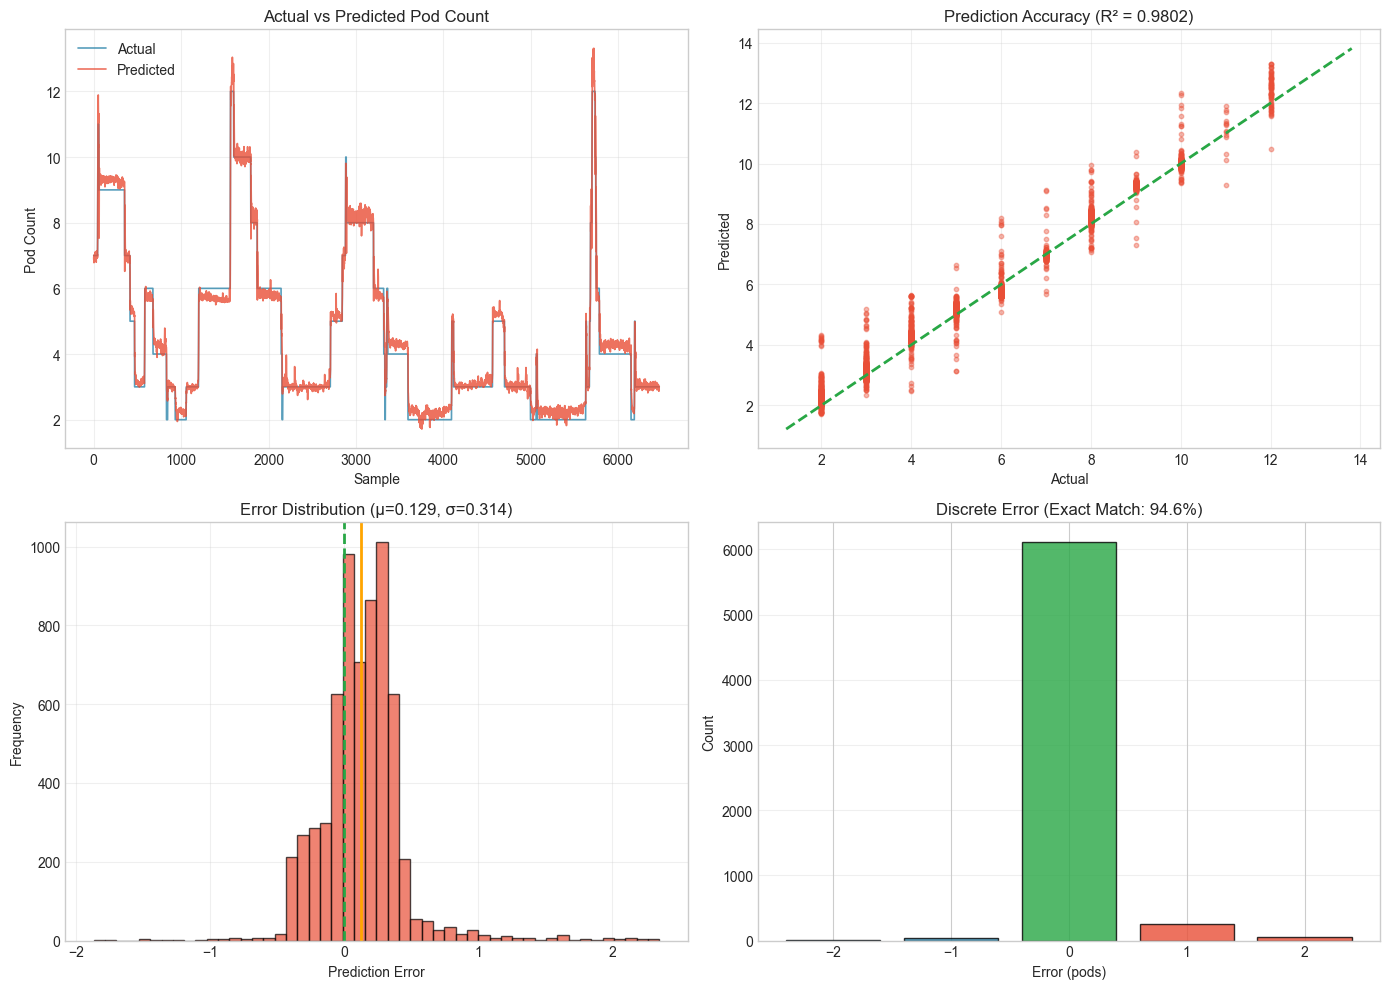

In [41]:
# =============================================================================
# Figure 1: Model Performance Overview
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Time Series
ax1 = axes[0, 0]
ax1.plot(y_test_pod_count, label='Actual', color='#2E86AB', linewidth=1.2, alpha=0.8)
ax1.plot(y_pred_pod_count, label='Predicted', color='#E94F37', linewidth=1.2, alpha=0.8)
ax1.set_xlabel('Sample')
ax1.set_ylabel('Pod Count')
ax1.set_title('Actual vs Predicted Pod Count')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Scatter Plot
ax2 = axes[0, 1]
ax2.scatter(y_test_pod_count, y_pred_pod_count, alpha=0.4, s=10, c='#E94F37')
lims = [min(y_test_pod_count.min(), y_pred_pod_count.min()) - 0.5,
        max(y_test_pod_count.max(), y_pred_pod_count.max()) + 0.5]
ax2.plot(lims, lims, '--', color='#28A745', linewidth=2)
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title(f'Prediction Accuracy (R² = {r2:.4f})')
ax2.grid(True, alpha=0.3)

# 3. Error Distribution
ax3 = axes[1, 0]
ax3.hist(errors, bins=50, color='#E94F37', alpha=0.7, edgecolor='black')
ax3.axvline(0, color='#28A745', linestyle='--', linewidth=2)
ax3.axvline(mean_error, color='orange', linestyle='-', linewidth=2)
ax3.set_xlabel('Prediction Error')
ax3.set_ylabel('Frequency')
ax3.set_title(f'Error Distribution (μ={mean_error:.3f}, σ={std_error:.3f})')
ax3.grid(True, alpha=0.3)

# 4. Discrete Error
ax4 = axes[1, 1]
error_rounded = y_pred_rounded - y_test_int
unique_errors, counts = np.unique(error_rounded, return_counts=True)
colors = ['#28A745' if e == 0 else '#E94F37' if e > 0 else '#2E86AB' for e in unique_errors]
ax4.bar(unique_errors, counts, color=colors, edgecolor='black', alpha=0.8)
ax4.set_xlabel('Error (pods)')
ax4.set_ylabel('Count')
ax4.set_title(f'Discrete Error (Exact Match: {exact_accuracy:.1f}%)')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/fig1_model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Performance by Workload Intensity

In [42]:
# Performance by pod count range
pod_ranges = [(0, 3, 'Low (1-3)'), (4, 6, 'Medium (4-6)'), 
              (7, 10, 'High (7-10)'), (11, float('inf'), 'Very High (11+)')]

range_metrics = []
for low, high, label in pod_ranges:
    mask = (y_test_int >= low) & (y_test_int <= high)
    if mask.sum() > 1:
        range_metrics.append({
            'Range': label,
            'Samples': mask.sum(),
            'R²': r2_score(y_test_pod_count[mask], y_pred_pod_count[mask]),
            'MAE': mean_absolute_error(y_test_pod_count[mask], y_pred_pod_count[mask]),
            'Exact (%)': np.mean(y_pred_rounded[mask] == y_test_int[mask]) * 100,
            '±1 (%)': np.mean(np.abs(y_pred_rounded[mask] - y_test_int[mask]) <= 1) * 100
        })

range_df = pd.DataFrame(range_metrics)
range_df

,Range,Samples,R²,MAE,Exact (%),±1 (%)
0,Low (1-3),3273,0.659830,0.181743,96.028109,99.327834
1,Medium (4-6),2050,0.830923,0.300540,94.585366,98.975610
2,High (7-10),1062,0.837454,0.265691,93.502825,98.775895
3,Very High (11+),84,-2.275388,0.558752,50.000000,97.619048


## 8. Scaling Event Detection

In [43]:
# Scaling event detection
actual_changes = np.diff(y_test_int)
pred_changes = np.diff(y_pred_rounded)

actual_scale_up = actual_changes > 0
pred_scale_up = pred_changes > 0
actual_scale_down = actual_changes < 0
pred_scale_down = pred_changes < 0
actual_no_change = actual_changes == 0
pred_no_change = pred_changes == 0

def detection_metrics(actual, predicted):
    tp = np.sum(actual & predicted)
    fp = np.sum(~actual & predicted)
    fn = np.sum(actual & ~predicted)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return {'Precision': precision, 'Recall': recall, 'F1': f1}

scale_up_metrics = detection_metrics(actual_scale_up, pred_scale_up)
scale_down_metrics = detection_metrics(actual_scale_down, pred_scale_down)

direction_correct = ((actual_scale_up & pred_scale_up) | 
                     (actual_scale_down & pred_scale_down) | 
                     (actual_no_change & pred_no_change))
direction_accuracy = direction_correct.sum() / len(actual_changes) * 100

scaling_df = pd.DataFrame({
    'Event': ['Scale-Up', 'Scale-Down'],
    'Total': [actual_scale_up.sum(), actual_scale_down.sum()],
    'Precision': [scale_up_metrics['Precision'], scale_down_metrics['Precision']],
    'Recall': [scale_up_metrics['Recall'], scale_down_metrics['Recall']],
    'F1': [scale_up_metrics['F1'], scale_down_metrics['F1']]
})

print(f"Direction Accuracy: {direction_accuracy:.2f}%")
scaling_df

Direction Accuracy: 96.74%


,Event,Total,Precision,Recall,F1
0,Scale-Up,50,0.271739,0.500000,0.352113
1,Scale-Down,29,0.021277,0.068966,0.032520


## 9. Baseline Comparison

In [44]:
# =============================================================================
# Baseline Methods
# =============================================================================

# Naive (t-1)
naive_pred = y_test_int[:-1]
naive_actual = y_test_int[1:]
naive_r2 = r2_score(naive_actual, naive_pred)
naive_mae = mean_absolute_error(naive_actual, naive_pred)
naive_exact = np.mean(naive_pred == naive_actual) * 100

# Moving Average (3)
ma_window = 3
ma_pred = np.array([np.mean(y_test_int[max(0, i-ma_window):i]) for i in range(ma_window, len(y_test_int))])
ma_pred_rounded = np.round(ma_pred).astype(int)
ma_actual = y_test_int[ma_window:]
ma_r2 = r2_score(ma_actual, ma_pred)
ma_mae = mean_absolute_error(ma_actual, ma_pred)
ma_exact = np.mean(ma_pred_rounded == ma_actual) * 100

# Linear Trend
x_trend = np.arange(len(y_test_int))
slope, intercept, _, _, _ = stats.linregress(x_trend, y_test_int)
trend_pred = slope * x_trend + intercept
trend_pred_rounded = np.round(trend_pred).astype(int)
trend_actual = y_test_int
trend_r2 = r2_score(trend_actual, trend_pred) if len(trend_actual) > 1 else 0
trend_mae = mean_absolute_error(trend_actual, trend_pred)
trend_exact = np.mean(trend_pred_rounded == trend_actual) * 100

# Comparison table
comparison_df = pd.DataFrame({
    'Method': ['Informer', 'Naive (t-1)', 'Moving Avg', 'Linear Trend'],
    'R²': [r2, naive_r2, ma_r2, trend_r2],
    'MAE': [mae, naive_mae, ma_mae, trend_mae],
    'Exact Match (%)': [exact_accuracy, naive_exact, ma_exact, trend_exact]
})

comparison_df

,Method,R²,MAE,Exact Match (%)
0,Informer,0.980187,0.238066,94.558664
1,Naive (t-1),0.995602,0.016698,98.778602
2,Moving Avg,0.991254,0.033406,97.587380
3,Linear Trend,0.210225,1.689490,18.735508


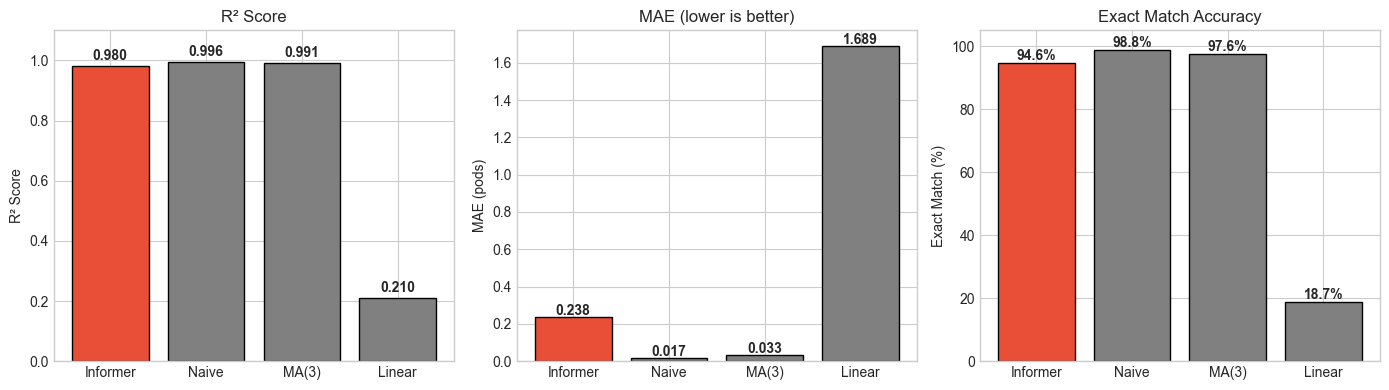

In [45]:
# =============================================================================
# Figure 2: Baseline Comparison
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
methods = ['Informer', 'Naive', 'MA(3)', 'Linear']
colors = ['#E94F37', '#808080', '#808080', '#808080']

# R²
axes[0].bar(methods, [r2, naive_r2, ma_r2, trend_r2], color=colors, edgecolor='black')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score')
axes[0].set_ylim(0, 1.1)
for i, v in enumerate([r2, naive_r2, ma_r2, trend_r2]):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# MAE
axes[1].bar(methods, [mae, naive_mae, ma_mae, trend_mae], color=colors, edgecolor='black')
axes[1].set_ylabel('MAE (pods)')
axes[1].set_title('MAE (lower is better)')
for i, v in enumerate([mae, naive_mae, ma_mae, trend_mae]):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Exact Match
axes[2].bar(methods, [exact_accuracy, naive_exact, ma_exact, trend_exact], color=colors, edgecolor='black')
axes[2].set_ylabel('Exact Match (%)')
axes[2].set_title('Exact Match Accuracy')
axes[2].set_ylim(0, 105)
for i, v in enumerate([exact_accuracy, naive_exact, ma_exact, trend_exact]):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results/fig2_baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. HPA (Horizontal Pod Autoscaler) Comparison

In [46]:
# =============================================================================
# HPA Simulation
# =============================================================================
# HPA = Reactive (scales after threshold exceeded)
# Informer = Proactive (predicts before demand spike)

# HPA Configuration
HPA_CONFIG = {
    'target_cpu': 70,
    'scale_up_delay': 0,
    'scale_down_delay': 5,
    'min_pods': 1,
    'max_pods': 20
}

# Simulate CPU data
try:
    cpu_idx = feature_cols.index('pod_cpu_usage_percent_avg')
    cpu_data = test_df[feature_cols].values[LOOKBACK:, cpu_idx]
except:
    cpu_data = y_test_int * 10 + np.random.normal(0, 5, len(y_test_int))
    cpu_data = np.clip(cpu_data, 10, 100)

def simulate_hpa(cpu, actual_pods, config):
    """Simulate Kubernetes HPA reactive scaling."""
    n = len(cpu)
    hpa_pods = np.zeros(n, dtype=int)
    hpa_pods[0] = actual_pods[0]
    scale_down_counter = 0
    
    for i in range(1, n):
        current = hpa_pods[i-1]
        desired = int(np.ceil(current * (cpu[i] / config['target_cpu'])))
        desired = np.clip(desired, config['min_pods'], config['max_pods'])
        
        if desired > current:
            hpa_pods[i] = min(current + 2, desired, config['max_pods'])
            scale_down_counter = 0
        elif desired < current:
            scale_down_counter += 1
            if scale_down_counter >= config['scale_down_delay']:
                hpa_pods[i] = max(current - 1, desired, config['min_pods'])
                scale_down_counter = 0
            else:
                hpa_pods[i] = current
        else:
            hpa_pods[i] = current
            scale_down_counter = 0
    
    return hpa_pods

# Run HPA simulation
hpa_pods = simulate_hpa(cpu_data, y_test_int, HPA_CONFIG)

# HPA metrics
hpa_r2 = r2_score(y_test_int, hpa_pods)
hpa_rmse = np.sqrt(mean_squared_error(y_test_int, hpa_pods))
hpa_mae = mean_absolute_error(y_test_int, hpa_pods)
hpa_exact = np.mean(hpa_pods == y_test_int) * 100
hpa_within_1 = np.mean(np.abs(hpa_pods - y_test_int) <= 1) * 100

In [47]:
# =============================================================================
# Resource Efficiency Analysis
# =============================================================================

def analyze_provisioning(actual, predicted):
    """Calculate under/over provisioning."""
    errors = predicted - actual
    return {
        'under_provision': np.sum(np.where(errors < 0, -errors, 0)),
        'over_provision': np.sum(np.where(errors > 0, errors, 0))
    }

informer_prov = analyze_provisioning(y_test_int, y_pred_rounded)
hpa_prov = analyze_provisioning(y_test_int, hpa_pods)

# Informer vs HPA comparison table
hpa_comparison_df = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'MAE', 'Exact Match (%)', 'Within ±1 (%)', 
               'Under-provisioning', 'Over-provisioning'],
    'Informer': [r2, rmse, mae, exact_accuracy, within_1_accuracy, 
                 informer_prov['under_provision'], informer_prov['over_provision']],
    'HPA': [hpa_r2, hpa_rmse, hpa_mae, hpa_exact, hpa_within_1,
            hpa_prov['under_provision'], hpa_prov['over_provision']]
})

hpa_comparison_df['Winner'] = hpa_comparison_df.apply(
    lambda row: 'Informer' if (
        (row['Metric'] in ['R²', 'Exact Match (%)', 'Within ±1 (%)'] and row['Informer'] > row['HPA']) or
        (row['Metric'] in ['RMSE', 'MAE', 'Under-provisioning', 'Over-provisioning'] and row['Informer'] < row['HPA'])
    ) else 'HPA', axis=1
)

hpa_comparison_df

,Metric,Informer,HPA,Winner
0,R²,0.980187,-2.041364,Informer
1,RMSE,0.340034,4.212933,Informer
2,MAE,0.238066,3.453239,Informer
3,Exact Match (%),94.558664,0.077292,Informer
4,Within ±1 (%),99.103416,20.451384,Informer
5,Under-provisioning,53.000000,22339.000000,Informer
6,Over-provisioning,357.000000,0.000000,HPA


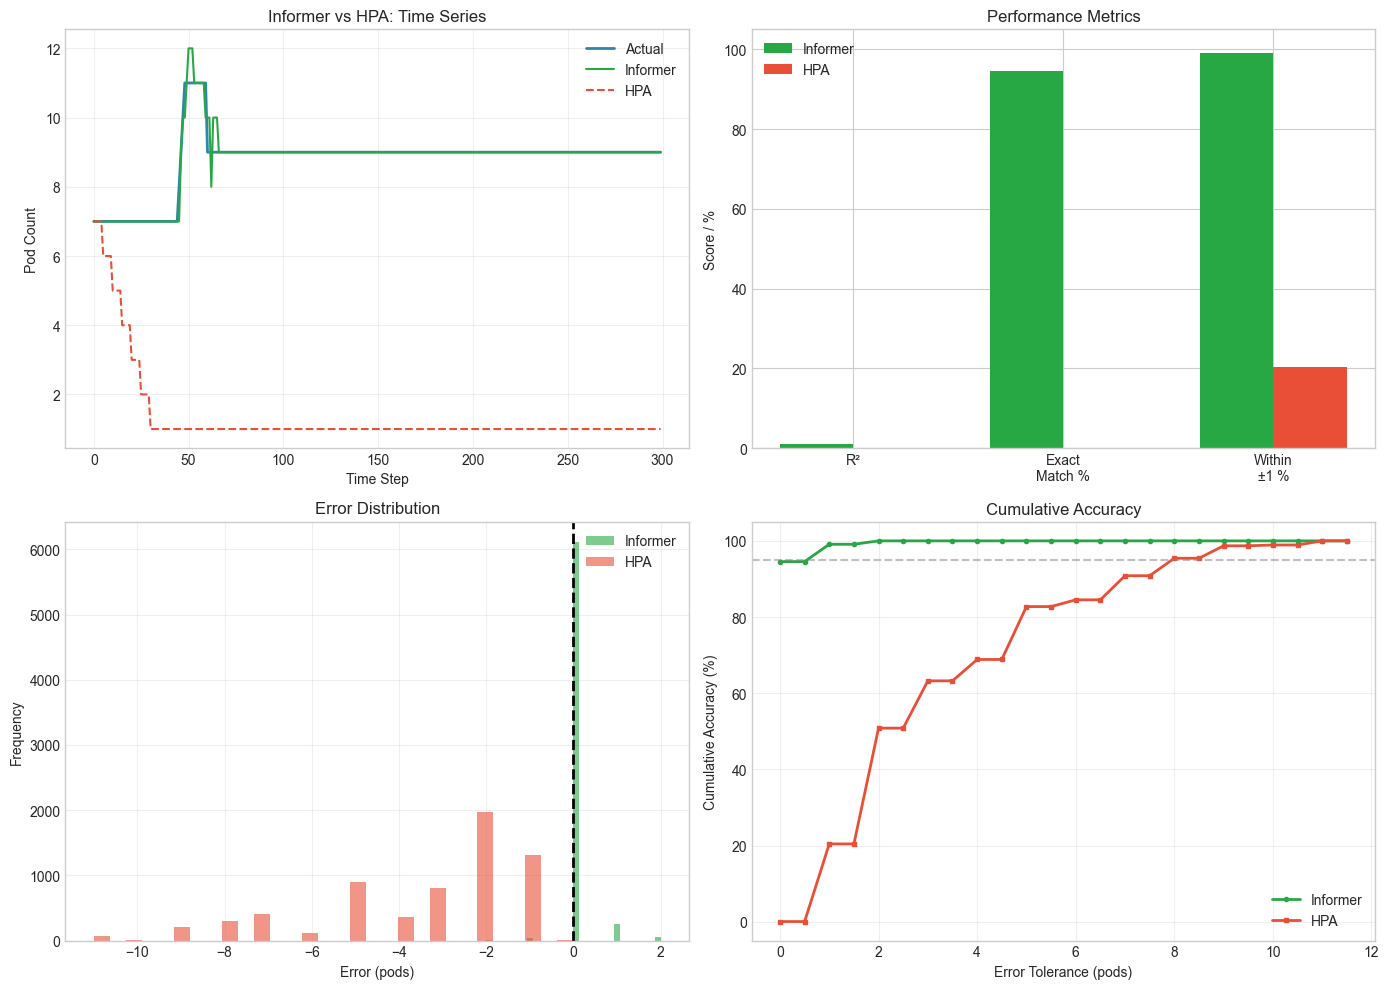

In [48]:
# =============================================================================
# Figure 3: Informer vs HPA Comparison
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Time Series
ax1 = axes[0, 0]
sample_size = min(300, len(y_test_int))
ax1.plot(range(sample_size), y_test_int[:sample_size], label='Actual', color='#2E86AB', linewidth=2)
ax1.plot(range(sample_size), y_pred_rounded[:sample_size], label='Informer', color='#28A745', linewidth=1.5)
ax1.plot(range(sample_size), hpa_pods[:sample_size], label='HPA', color='#E94F37', linewidth=1.5, linestyle='--')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Pod Count')
ax1.set_title('Informer vs HPA: Time Series')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Metrics Comparison
ax2 = axes[0, 1]
metrics = ['R²', 'Exact\nMatch %', 'Within\n±1 %']
informer_vals = [r2, exact_accuracy, within_1_accuracy]
hpa_vals = [hpa_r2, hpa_exact, hpa_within_1]
x = np.arange(len(metrics))
width = 0.35
ax2.bar(x - width/2, informer_vals, width, label='Informer', color='#28A745')
ax2.bar(x + width/2, hpa_vals, width, label='HPA', color='#E94F37')
ax2.set_ylabel('Score / %')
ax2.set_title('Performance Metrics')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.set_ylim(0, 105)

# 3. Error Distribution
ax3 = axes[1, 0]
ax3.hist(y_pred_rounded - y_test_int, bins=30, alpha=0.6, label='Informer', color='#28A745')
ax3.hist(hpa_pods - y_test_int, bins=30, alpha=0.6, label='HPA', color='#E94F37')
ax3.axvline(0, color='black', linestyle='--', linewidth=2)
ax3.set_xlabel('Error (pods)')
ax3.set_ylabel('Frequency')
ax3.set_title('Error Distribution')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Cumulative Accuracy
ax4 = axes[1, 1]
informer_errors = np.abs(y_pred_rounded - y_test_int)
hpa_errors = np.abs(hpa_pods - y_test_int)
thresholds = np.arange(0, max(informer_errors.max(), hpa_errors.max()) + 1, 0.5)
informer_cum = [np.mean(informer_errors <= t) * 100 for t in thresholds]
hpa_cum = [np.mean(hpa_errors <= t) * 100 for t in thresholds]
ax4.plot(thresholds, informer_cum, label='Informer', color='#28A745', linewidth=2, marker='o', markersize=3)
ax4.plot(thresholds, hpa_cum, label='HPA', color='#E94F37', linewidth=2, marker='s', markersize=3)
ax4.axhline(95, color='gray', linestyle='--', alpha=0.5)
ax4.set_xlabel('Error Tolerance (pods)')
ax4.set_ylabel('Cumulative Accuracy (%)')
ax4.set_title('Cumulative Accuracy')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/fig3_informer_vs_hpa.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Summary Results

In [49]:
# =============================================================================
# Final Summary Table
# =============================================================================

# All methods comparison
all_methods_df = pd.DataFrame({
    'Method': ['Informer', 'HPA', 'Naive (t-1)', 'Moving Avg (3)', 'Linear Trend'],
    'Type': ['Proactive', 'Reactive', 'Baseline', 'Baseline', 'Baseline'],
    'R²': [r2, hpa_r2, naive_r2, ma_r2, trend_r2],
    'RMSE': [rmse, hpa_rmse, np.sqrt(mean_squared_error(naive_actual, naive_pred)), 
             np.sqrt(mean_squared_error(ma_actual, ma_pred)), np.sqrt(mean_squared_error(trend_actual, trend_pred))],
    'MAE': [mae, hpa_mae, naive_mae, ma_mae, trend_mae],
    'Exact Match (%)': [exact_accuracy, hpa_exact, naive_exact, ma_exact, trend_exact]
})

all_methods_df

,Method,Type,R²,RMSE,MAE,Exact Match (%)
0,Informer,Proactive,0.980187,0.340034,0.238066,94.558664
1,HPA,Reactive,-2.041364,4.212933,3.453239,0.077292
2,Naive (t-1),Baseline,0.995602,0.160202,0.016698,98.778602
3,Moving Avg (3),Baseline,0.991254,0.225912,0.033406,97.587380
4,Linear Trend,Baseline,0.210225,2.146851,1.689490,18.735508


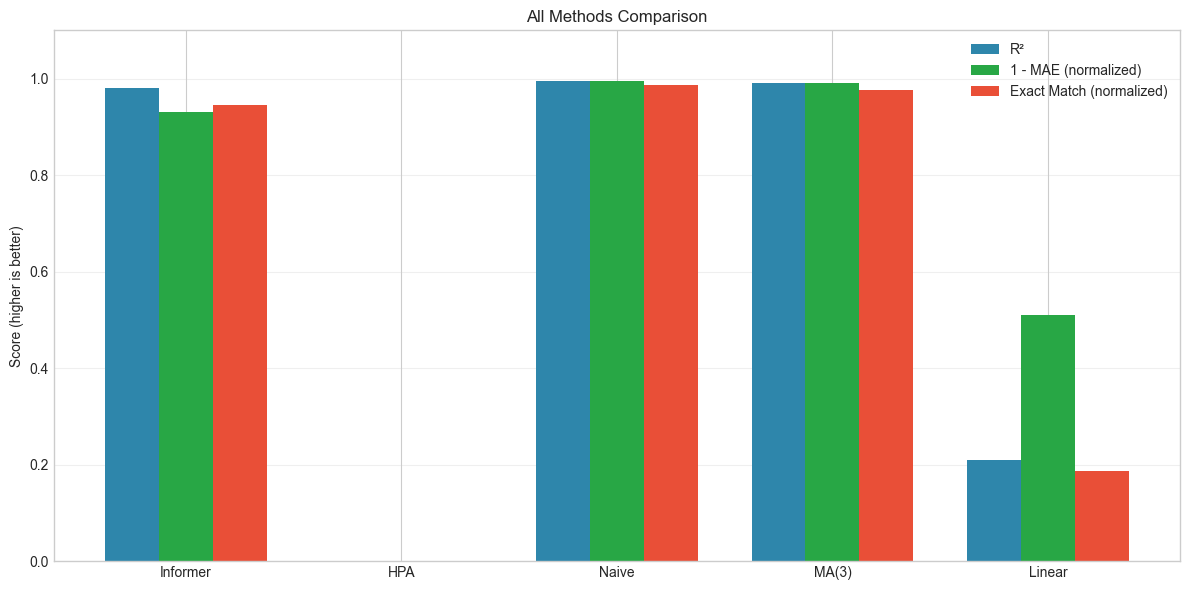

In [50]:
# =============================================================================
# Figure 4: All Methods Comparison
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

methods = ['Informer', 'HPA', 'Naive', 'MA(3)', 'Linear']
x = np.arange(len(methods))
width = 0.25

r2_vals = [r2, hpa_r2, naive_r2, ma_r2, trend_r2]
mae_vals = [mae, hpa_mae, naive_mae, ma_mae, trend_mae]
exact_vals = [exact_accuracy, hpa_exact, naive_exact, ma_exact, trend_exact]

# Normalize for visualization
mae_norm = [1 - (m / max(mae_vals)) for m in mae_vals]  # Invert so higher is better
exact_norm = [e / 100 for e in exact_vals]

ax.bar(x - width, r2_vals, width, label='R²', color='#2E86AB')
ax.bar(x, mae_norm, width, label='1 - MAE (normalized)', color='#28A745')
ax.bar(x + width, exact_norm, width, label='Exact Match (normalized)', color='#E94F37')

ax.set_ylabel('Score (higher is better)')
ax.set_title('All Methods Comparison')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/fig4_all_methods.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Elasticity Metrics (Θ_U, Θ_O, T_U, T_O)

In [51]:
# =============================================================================
# Elasticity Evaluation Constants
# =============================================================================

# Workload capacity per pod (requests/minute or similar)
WORKLOAD_PER_POD = 100

# Resource Reservation Scale (for scale-down smoothing)
RRS = 0.6

# Minimum pods
MIN_PODS = 1

# Total time period (in minutes) - adjust based on your data granularity
TOTAL_TIME = len(y_test_int)  # Each sample = 1 time unit

In [52]:
# =============================================================================
# Calculate Elasticity Metrics
# =============================================================================

def calculate_elasticity_metrics(actual_pods, predicted_pods, workload_per_pod, total_time):
    """
    Calculate elasticity metrics for autoscaler evaluation.
    
    Θ_U: Under-provisioning percentage (resource shortage)
    Θ_O: Over-provisioning percentage (resource waste)
    T_U: Time percentage in under-provisioned state
    T_O: Time percentage in over-provisioned state
    """
    # Resource demand (r_t) and provisioned capacity (p_t)
    r_t = actual_pods  # Actual required pods
    p_t = predicted_pods  # Predicted/provisioned pods
    
    # Under-provisioning: when predicted < actual (not enough resources)
    under_provisioning = np.maximum(r_t - p_t, 0)
    
    # Over-provisioning: when predicted > actual (wasted resources)
    over_provisioning = np.maximum(p_t - r_t, 0)
    
    # Sign indicators for time calculation
    sgn_under = np.where(r_t > p_t, 1, 0)
    sgn_over = np.where(p_t > r_t, 1, 0)
    
    # Elasticity metrics
    # Θ_U: Average under-provisioning relative to demand
    Θ_U = (100 / total_time) * np.sum(under_provisioning / np.maximum(r_t, 1))
    
    # Θ_O: Average over-provisioning relative to demand
    Θ_O = (100 / total_time) * np.sum(over_provisioning / np.maximum(r_t, 1))
    
    # T_U: Percentage of time under-provisioned
    T_U = (100 / total_time) * np.sum(sgn_under)
    
    # T_O: Percentage of time over-provisioned
    T_O = (100 / total_time) * np.sum(sgn_over)
    
    return {
        'Θ_U': Θ_U,
        'Θ_O': Θ_O,
        'T_U': T_U,
        'T_O': T_O,
        'under_provisioning': under_provisioning,
        'over_provisioning': over_provisioning
    }

# Calculate for Informer
informer_elasticity = calculate_elasticity_metrics(
    y_test_int, y_pred_rounded, WORKLOAD_PER_POD, TOTAL_TIME
)

# Calculate for HPA
hpa_elasticity = calculate_elasticity_metrics(
    y_test_int, hpa_pods, WORKLOAD_PER_POD, TOTAL_TIME
)

# Calculate for Naive baseline
naive_elasticity = calculate_elasticity_metrics(
    y_test_int[1:], naive_pred, WORKLOAD_PER_POD, len(naive_pred)
)

In [53]:
# =============================================================================
# Elasticity Metrics Comparison Table
# =============================================================================

elasticity_df = pd.DataFrame({
    'Metric': ['Θ_U (Under-provisioning %)', 'Θ_O (Over-provisioning %)', 
               'T_U (Time Under %)', 'T_O (Time Over %)'],
    'Informer': [informer_elasticity['Θ_U'], informer_elasticity['Θ_O'],
                 informer_elasticity['T_U'], informer_elasticity['T_O']],
    'HPA': [hpa_elasticity['Θ_U'], hpa_elasticity['Θ_O'],
            hpa_elasticity['T_U'], hpa_elasticity['T_O']],
    'Naive': [naive_elasticity['Θ_U'], naive_elasticity['Θ_O'],
              naive_elasticity['T_U'], naive_elasticity['T_O']]
})

elasticity_df

,Metric,Informer,HPA,Naive
0,Θ_U (Under-provisioning %),0.132735,70.943546,0.154444
1,Θ_O (Over-provisioning %),1.559061,0.000000,0.245691
2,T_U (Time Under %),0.726542,99.922708,0.773036
3,T_O (Time Over %),4.714794,0.000000,0.448361


## 13. Elastic Speedup Calculation

In [54]:
# =============================================================================
# Elastic Speedup Formula
# =============================================================================
# ε_n = ((a * b * c * d) / (Θ_U * Θ_O * T_U * T_O)) ^ 0.25
# where a, b, c, d are benchmark constants

# Benchmark constants (from reference system)
BENCHMARK = {
    'a': 0.189,   # Reference Θ_U
    'b': 593.755, # Reference Θ_O  
    'c': 2.2,     # Reference T_U
    'd': 97.6     # Reference T_O
}

def calculate_elastic_speedup(metrics, benchmark):
    """Calculate elastic speedup relative to benchmark."""
    numerator = benchmark['a'] * benchmark['b'] * benchmark['c'] * benchmark['d']
    
    # Avoid division by zero
    Θ_U = max(metrics['Θ_U'], 0.001)
    Θ_O = max(metrics['Θ_O'], 0.001)
    T_U = max(metrics['T_U'], 0.001)
    T_O = max(metrics['T_O'], 0.001)
    
    denominator = Θ_U * Θ_O * T_U * T_O
    
    return (numerator / denominator) ** 0.25

# Calculate elastic speedup for each method
informer_speedup = calculate_elastic_speedup(informer_elasticity, BENCHMARK)
hpa_speedup = calculate_elastic_speedup(hpa_elasticity, BENCHMARK)
naive_speedup = calculate_elastic_speedup(naive_elasticity, BENCHMARK)

speedup_df = pd.DataFrame({
    'Method': ['Informer', 'HPA', 'Naive'],
    'Elastic Speedup (ε_n)': [informer_speedup, hpa_speedup, naive_speedup]
})

speedup_df

,Method,Elastic Speedup (ε_n)
0,Informer,13.578196
1,HPA,42.937932
2,Naive,36.790745


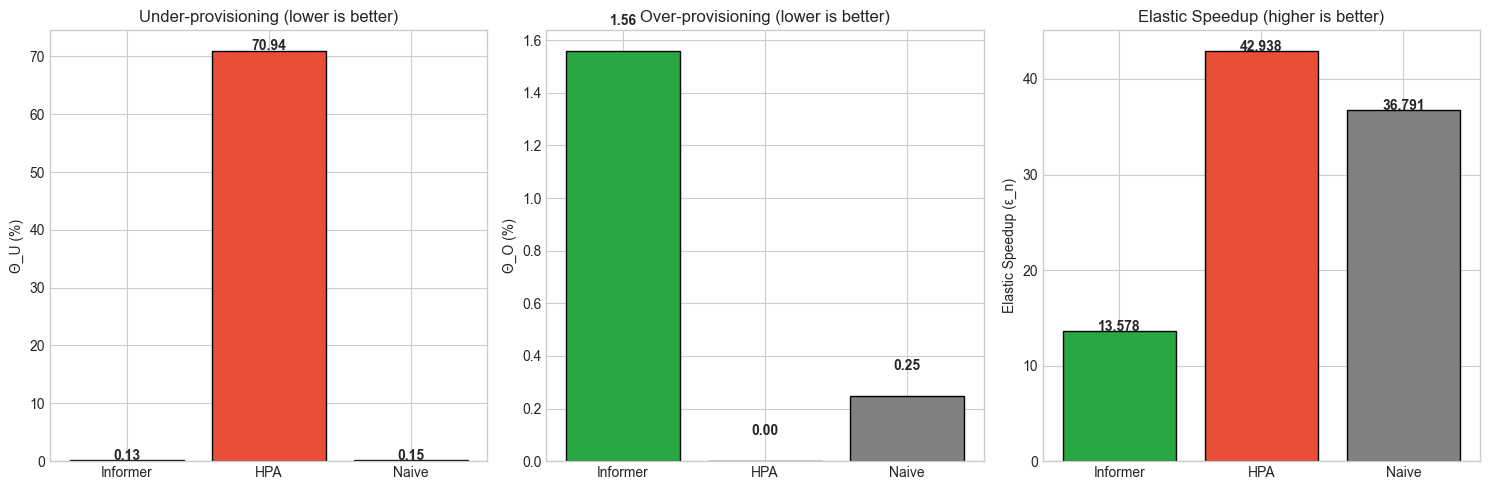

In [55]:
# =============================================================================
# Figure 5: Elasticity Metrics Comparison
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

methods = ['Informer', 'HPA', 'Naive']
colors = ['#28A745', '#E94F37', '#808080']

# 1. Under-provisioning (Θ_U) - Lower is better
ax1 = axes[0]
theta_u_vals = [informer_elasticity['Θ_U'], hpa_elasticity['Θ_U'], naive_elasticity['Θ_U']]
bars1 = ax1.bar(methods, theta_u_vals, color=colors, edgecolor='black')
ax1.set_ylabel('Θ_U (%)')
ax1.set_title('Under-provisioning (lower is better)')
for bar, val in zip(bars1, theta_u_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.2f}', ha='center', fontweight='bold')

# 2. Over-provisioning (Θ_O) - Lower is better
ax2 = axes[1]
theta_o_vals = [informer_elasticity['Θ_O'], hpa_elasticity['Θ_O'], naive_elasticity['Θ_O']]
bars2 = ax2.bar(methods, theta_o_vals, color=colors, edgecolor='black')
ax2.set_ylabel('Θ_O (%)')
ax2.set_title('Over-provisioning (lower is better)')
for bar, val in zip(bars2, theta_o_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', fontweight='bold')

# 3. Elastic Speedup - Higher is better
ax3 = axes[2]
speedup_vals = [informer_speedup, hpa_speedup, naive_speedup]
bars3 = ax3.bar(methods, speedup_vals, color=colors, edgecolor='black')
ax3.set_ylabel('Elastic Speedup (ε_n)')
ax3.set_title('Elastic Speedup (higher is better)')
for bar, val in zip(bars3, speedup_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results/fig5_elasticity_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

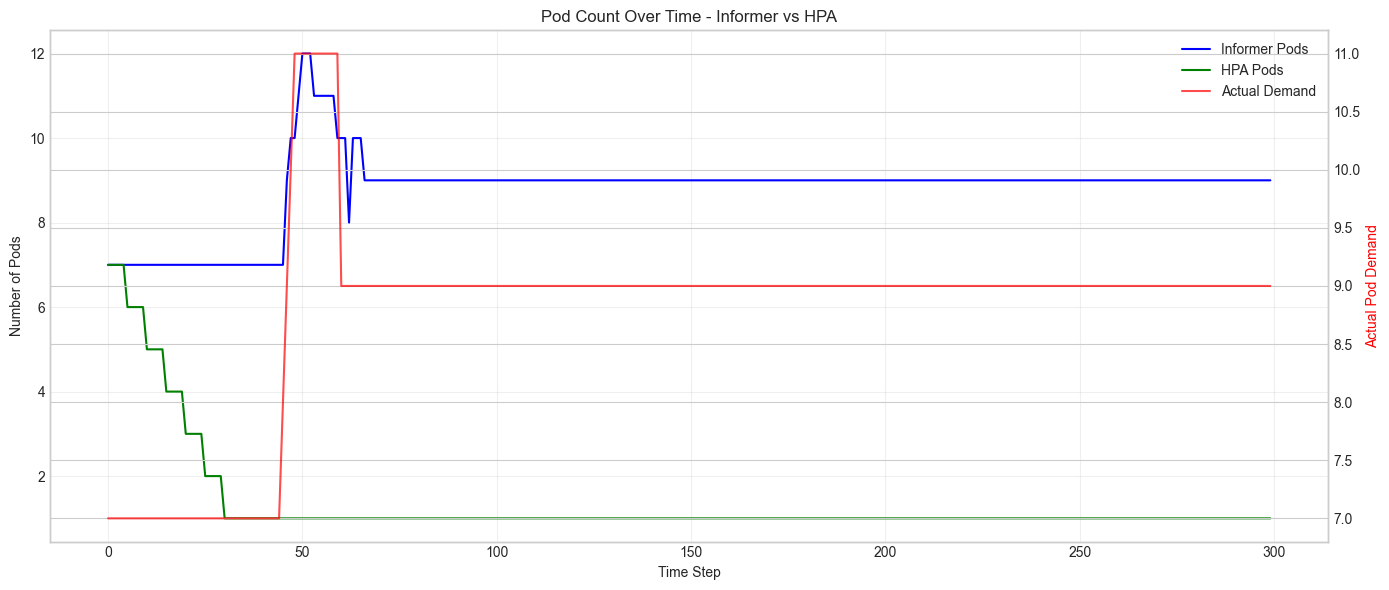

In [56]:
# =============================================================================
# Figure 6: Pod Count and Workload Over Time (Similar to friend's style)
# =============================================================================

fig, ax1 = plt.subplots(figsize=(14, 6))

sample_size = min(300, len(y_test_int))

# Pod counts on primary y-axis
line1, = ax1.plot(range(sample_size), y_pred_rounded[:sample_size], 
                   label='Informer Pods', color='blue', linewidth=1.5)
line2, = ax1.plot(range(sample_size), hpa_pods[:sample_size], 
                   label='HPA Pods', color='green', linewidth=1.5)
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Number of Pods')
ax1.grid(True, alpha=0.3)

# Actual demand on secondary y-axis
ax2 = ax1.twinx()
line3, = ax2.plot(range(sample_size), y_test_int[:sample_size], 
                   label='Actual Demand', color='red', linewidth=1.5, alpha=0.7)
ax2.set_ylabel('Actual Pod Demand', color='red')

# Combined legend
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

ax1.set_title('Pod Count Over Time - Informer vs HPA')
plt.tight_layout()
plt.savefig('results/fig6_pod_count_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Export Results

In [57]:
# Save all results
from datetime import datetime
os.makedirs('results', exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Export all DataFrames
eval_df.to_csv(f'results/predictions_{timestamp}.csv', index=False)
informer_metrics.to_csv(f'results/informer_metrics_{timestamp}.csv', index=False)
comparison_df.to_csv(f'results/baseline_comparison_{timestamp}.csv', index=False)
hpa_comparison_df.to_csv(f'results/hpa_comparison_{timestamp}.csv', index=False)
elasticity_df.to_csv(f'results/elasticity_metrics_{timestamp}.csv', index=False)
speedup_df.to_csv(f'results/elastic_speedup_{timestamp}.csv', index=False)

print(f"Results saved to 'results/' with timestamp: {timestamp}")

Results saved to 'results/' with timestamp: 20251211_120230


## 15. Final Summary

In [58]:
# =============================================================================
# Complete Evaluation Summary
# =============================================================================

summary_df = pd.DataFrame({
    'Metric': [
        'R² Score',
        'RMSE (pods)',
        'MAE (pods)',
        'Exact Match (%)',
        'Within ±1 Pod (%)',
        'Θ_U (Under-prov %)',
        'Θ_O (Over-prov %)',
        'T_U (Time Under %)',
        'T_O (Time Over %)',
        'Elastic Speedup (ε_n)'
    ],
    'Informer': [
        f'{r2:.4f}',
        f'{rmse:.4f}',
        f'{mae:.4f}',
        f'{exact_accuracy:.2f}',
        f'{within_1_accuracy:.2f}',
        f'{informer_elasticity["Θ_U"]:.4f}',
        f'{informer_elasticity["Θ_O"]:.4f}',
        f'{informer_elasticity["T_U"]:.2f}',
        f'{informer_elasticity["T_O"]:.2f}',
        f'{informer_speedup:.4f}'
    ],
    'HPA': [
        f'{hpa_r2:.4f}',
        f'{hpa_rmse:.4f}',
        f'{hpa_mae:.4f}',
        f'{hpa_exact:.2f}',
        f'{hpa_within_1:.2f}',
        f'{hpa_elasticity["Θ_U"]:.4f}',
        f'{hpa_elasticity["Θ_O"]:.4f}',
        f'{hpa_elasticity["T_U"]:.2f}',
        f'{hpa_elasticity["T_O"]:.2f}',
        f'{hpa_speedup:.4f}'
    ]
})

summary_df

,Metric,Informer,HPA
0,R² Score,0.9802,-2.0414
1,RMSE (pods),0.3400,4.2129
2,MAE (pods),0.2381,3.4532
3,Exact Match (%),94.56,0.08
4,Within ±1 Pod (%),99.10,20.45
5,Θ_U (Under-prov %),0.1327,70.9435
6,Θ_O (Over-prov %),1.5591,0.0000
7,T_U (Time Under %),0.73,99.92
8,T_O (Time Over %),4.71,0.00
9,Elastic Speedup (ε_n),13.5782,42.9379
